#### <span style="color:red">**Import all required libraries and packages**</span>


In [ ]:
%matplotlib inline
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from pathlib import Path
import re
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import LabelEncoder
import joblib
import sqlite3


# https://sbnmpc.astro.umd.edu/MPC_database/obs24.shtml


#### <span style="color:red">**Read dataset file and load it in a pandas dataframe**</span>


In [3]:
CWD = Path().cwd().parent
DATASET_DIR = CWD / 'Datasets'
nasa_csv = DATASET_DIR / 'NASA_NEO_Dataset.csv'
nasa_api = DATASET_DIR / 'NASA_NEO_Data_API.csv'
european_space_csv = DATASET_DIR / 'European_Space_Agency_NEOs_Scraped_Data.csv'

try:
    df = pd.read_csv(nasa_csv)
    df1 = pd.read_csv(nasa_api)
    df2 = pd.read_csv(european_space_csv)
except FileNotFoundError:
    print(f"Error: The file {nasa_csv} was not found.")
    exit(1)
print("Datasets loaded successfully.")

Datasets loaded successfully.


<span style="color:red">**Dataset 1: Kaggle**</span>

In [4]:
df.head()

,Neo Reference ID,Name,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),Est Dia in Feet(min),...,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion,Equinox,Hazardous
0,3703080,3703080,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,314.373913,609.599786,0.808259,57.257470,2.005764,2.458162e+06,264.837533,0.590551,J2000,True
1,3723955,3723955,21.3,0.146068,0.326618,146.067964,326.617897,0.090762,0.202951,479.225620,...,136.717242,425.869294,0.718200,313.091975,1.497352,2.457795e+06,173.741112,0.845330,J2000,False
2,2446862,2446862,20.3,0.231502,0.517654,231.502122,517.654482,0.143849,0.321655,759.521423,...,259.475979,643.580228,0.950791,248.415038,1.966857,2.458120e+06,292.893654,0.559371,J2000,True
3,3092506,3092506,27.4,0.008801,0.019681,8.801465,19.680675,0.005469,0.012229,28.876199,...,57.173266,514.082140,0.983902,18.707701,1.527904,2.457902e+06,68.741007,0.700277,J2000,False
4,3514799,3514799,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,84.629307,495.597821,0.967687,158.263596,1.483543,2.457814e+06,135.142133,0.726395,J2000,True


<span style="color:red">**Dataset 2: NASA API**</span>

In [5]:
df1.head()

,Absolute_Magnitude,Est_Dia_In_Km_Min,Est_Dia_In_Km_Max,Close_Approach_Date,Relative_Velocity_Km_Per_Hr,Miss_Dist_Kilometers,Minimum_Orbit_Intersection,Jupiter_Tisserand_Invariant,Epoch_Osculation,Eccentricity,...,Inclination,Asc_Node_Longitude,Orbital_Period,Perihelion_Distance,Perihelion_Arg,Aphelion_Dist,Perihelion_Time,Mean_Anomaly,Mean_Motion,Hazardous
0,15.26,2.358061,5.272784,1901-08-23,42346.121107,5.071251e+06,0.029359,5.074,2461000.5,0.335512,...,13.335793,337.140792,507.877358,0.827804,277.018390,1.663750,2.461208e+06,212.920449,0.708833,True
1,15.46,2.150577,4.808836,1907-10-11,65086.250032,1.337870e+07,0.187310,3.297,2461000.5,0.606266,...,18.378651,345.551216,1241.064828,0.889883,269.074546,3.630348,2.461243e+06,289.564484,0.290073,False
2,18.38,0.560473,1.253257,1906-03-06,54435.550108,3.789658e+06,0.108832,3.122,2461000.5,0.570225,...,20.399239,162.921649,1482.823498,1.093710,347.755255,3.995972,2.460911e+06,21.616448,0.242780,False
3,14.38,3.536348,7.907514,1926-09-28,54844.163368,1.687224e+07,0.071704,3.435,2461000.5,0.505538,...,23.958779,188.274896,1150.717205,1.062625,194.552572,3.235478,2.460489e+06,160.089498,0.312848,False
4,17.21,0.960627,2.148028,1903-03-06,37400.803776,9.959875e+06,0.066744,5.668,2461000.5,0.349429,...,9.434707,33.036303,408.813985,0.701315,55.350732,1.454683,2.461143e+06,234.787011,0.880596,False


<span style="color:red">**Dataset 3: European Space Agency Webscraping**</span>

In [6]:
df2.head()

,ID,Absolute_Magnitude,Est_Dia_In_Km_Min,Est_Dia_In_Km_Max,Close_Approach_Date,Relative_Velocity_Km_Per_Hr,Miss_Dist_Kilometers,Minimum_Orbit_Intersection,Jupiter_Tisserand_Invariant,Epoch_Osculation,...,Inclination,Asc_Node_Longitude,Orbital_Period,Perihelion_Distance,Perihelion_Arg,Aphelion_Dist,Perihelion_Time,Mean_Anomaly,Mean_Motion,Hazardous
0,100004 1983VA,16.5,2.404,2.404,2063-11-15,58894.076571,0.15117,0.17434,2.975337,2461000.5,...,15.7,76.2933,1522.4,0.770,13.7515,4.410,2.461052e+06,347.84318,0.236469,False
1,100085 1992UY4,17.8,NaN,NaN,-,39880.736050,NaN,0.02485,3.082842,2461000.5,...,2.6,305.1694,1576.8,1.011,42.2368,4.292,2.461484e+06,249.67319,0.228311,NaN
2,100756 1998FM5,16.3,1.800,1.800,2039-02-14,30578.015416,0.13701,0.09296,3.372929,2461000.5,...,11.6,176.5014,1244.9,1.009,312.0578,3.521,2.460831e+06,48.89507,0.289180,False
3,100926 1998MQ,16.7,1.500,1.500,2029-11-01,57020.825827,0.19991,0.12928,3.893863,2461000.5,...,24.2,221.0728,869.4,1.056,138.8093,2.509,2.460674e+06,135.12454,0.414079,False
4,10115 1992SK,17.1,0.930,0.930,2031-08-25,37211.920406,0.19925,0.04641,5.061511,2461000.5,...,15.3,8.8702,509.6,0.843,233.7358,1.654,2.460990e+06,7.07529,0.706436,False


#### <span style="color:red">**Column names**</span>


In [7]:
columns = df.columns
print('df Column names:')
print(columns)

columns = df1.columns
print('df1 Column names:')
print(columns)

columns = df2.columns
print('df2 Column names:')
print(columns)



df Column names:
Index(['Neo Reference ID', 'Name', 'Absolute Magnitude', 'Est Dia in KM(min)',
       'Est Dia in KM(max)', 'Est Dia in M(min)', 'Est Dia in M(max)',
       'Est Dia in Miles(min)', 'Est Dia in Miles(max)',
       'Est Dia in Feet(min)', 'Est Dia in Feet(max)', 'Close Approach Date',
       'Epoch Date Close Approach', 'Relative Velocity km per sec',
       'Relative Velocity km per hr', 'Miles per hour',
       'Miss Dist.(Astronomical)', 'Miss Dist.(lunar)',
       'Miss Dist.(kilometers)', 'Miss Dist.(miles)', 'Orbiting Body',
       'Orbit ID', 'Orbit Determination Date', 'Orbit Uncertainity',
       'Minimum Orbit Intersection', 'Jupiter Tisserand Invariant',
       'Epoch Osculation', 'Eccentricity', 'Semi Major Axis', 'Inclination',
       'Asc Node Longitude', 'Orbital Period', 'Perihelion Distance',
       'Perihelion Arg', 'Aphelion Dist', 'Perihelion Time', 'Mean Anomaly',
       'Mean Motion', 'Equinox', 'Hazardous'],
      dtype='object')
df1 Column names:

#### <span style="color:red">**Standardize column in df names by removing spaces, dots, paranthesis and converting into Title Case**</span>


In [8]:
df.columns = (
    df.columns
    .str.lower() 
    .str.replace('[^0-9a-zA-Z]+', '_', regex=True) 
    .str.strip('_')
    .str.title()
)
print('Normalized Column names:')
df.columns

Normalized Column names:


Index(['Neo_Reference_Id', 'Name', 'Absolute_Magnitude', 'Est_Dia_In_Km_Min',
       'Est_Dia_In_Km_Max', 'Est_Dia_In_M_Min', 'Est_Dia_In_M_Max',
       'Est_Dia_In_Miles_Min', 'Est_Dia_In_Miles_Max', 'Est_Dia_In_Feet_Min',
       'Est_Dia_In_Feet_Max', 'Close_Approach_Date',
       'Epoch_Date_Close_Approach', 'Relative_Velocity_Km_Per_Sec',
       'Relative_Velocity_Km_Per_Hr', 'Miles_Per_Hour',
       'Miss_Dist_Astronomical', 'Miss_Dist_Lunar', 'Miss_Dist_Kilometers',
       'Miss_Dist_Miles', 'Orbiting_Body', 'Orbit_Id',
       'Orbit_Determination_Date', 'Orbit_Uncertainity',
       'Minimum_Orbit_Intersection', 'Jupiter_Tisserand_Invariant',
       'Epoch_Osculation', 'Eccentricity', 'Semi_Major_Axis', 'Inclination',
       'Asc_Node_Longitude', 'Orbital_Period', 'Perihelion_Distance',
       'Perihelion_Arg', 'Aphelion_Dist', 'Perihelion_Time', 'Mean_Anomaly',
       'Mean_Motion', 'Equinox', 'Hazardous'],
      dtype='object')

#### <span style="color:red">**Reduce the number of columns in df that don't add information**</span>


| Column                       | Description                        | Keep/Drop | Reason                                       |
| ---------------------------- | ---------------------------------- | --------- | -------------------------------------------- |
| Neo_Reference_Id             | Unique asteroid ID                 | ❌         | Identifier only, not useful for analysis     |
| Name                         | Asteroid name                      | ❌         | Text, not needed for math/ML                 |
| Absolute_Magnitude           | Brightness of asteroid             | ✅         | Numeric, relevant for size & hazard analysis |
| Est_Dia_In_Km_Min            | Minimum estimated diameter (km)    | ✅         | Useful for size features                     |
| Est_Dia_In_Km_Max            | Maximum estimated diameter (km)    | ✅         | Useful for size features                     |
| Est_Dia_In_M_Min             | Minimum estimated diameter (m)     | ❌         | Redundant, km columns suffice                |
| Est_Dia_In_M_Max             | Maximum estimated diameter (m)     | ❌         | Redundant                                    |
| Est_Dia_In_Miles_Min         | Min diameter in miles              | ❌         | Redundant                                    |
| Est_Dia_In_Miles_Max         | Max diameter in miles              | ❌         | Redundant                                    |
| Est_Dia_In_Feet_Min          | Min diameter in feet               | ❌         | Redundant                                    |
| Est_Dia_In_Feet_Max          | Max diameter in feet               | ❌         | Redundant                                    |
| Close_Approach_Date          | Date of close approach             | ✅         | Useful for time-based analysis               |
| Epoch_Date_Close_Approach    | Epoch timestamp                    | ❌         | Redundant if you have date already           |
| Relative_Velocity_Km_Per_Sec | Speed in km/s                      | ❌         | Keep km/hr instead                           |
| Relative_Velocity_Km_Per_Hr  | Speed in km/hr                     | ✅         | Main velocity feature                        |
| Miles_Per_Hour               | Speed in mph                       | ❌         | Redundant, Keep km/hr instead                |
| Miss_Dist_Astronomical       | Distance in AU                     | ❌         | Keep km instead                              |
| Miss_Dist_Lunar              | Distance in lunar units            | ❌         | Keep km instead                              |
| Miss_Dist_Kilometers         | Distance from Earth in km          | ✅         | Important numeric feature                    |
| Miss_Dist_Miles              | Distance in miles                  | ❌         | Keep km instead                              |
| Orbiting_Body                | Planet the asteroid approached     | ❌         | All values are 'Earth'                        |
| Orbit_Id                     | Orbit ID                           | ❌         | Administrative, not needed                   |
| Orbit_Determination_Date     | Orbit determination date           | ❌         | Not needed                                   |
| Orbit_Uncertainity           | Orbit uncertainty                  | ❌         | Optional, can remove                         |
| Minimum_Orbit_Intersection   | Closest orbit intersection         | ✅         | Scientifically relevant                      |
| Jupiter_Tisserand_Invariant  | Orbital parameter                  | ✅         | Useful for analysis                          |
| Epoch_Osculation             | Orbital epoch                      | ✅         | Calculate position at any time               |
| Eccentricity                 | Orbital eccentricity               | ✅         | Numeric feature                              |
| Semi_Major_Axis              | Semi-major axis                    | ✅         | Numeric feature                              |
| Inclination                  | Orbital inclination                | ✅         | Numeric feature                              |
| Asc_Node_Longitude           | Longitude of ascending node        | ✅         | Numeric feature                              |
| Orbital_Period               | Orbital period                     | ✅         | Numeric feature                              |
| Perihelion_Distance          | Perihelion distance                | ✅         | Numeric feature                              |
| Perihelion_Arg               | Perihelion argument                | ✅         | Numeric feature                              |
| Aphelion_Dist                | Aphelion distance                  | ✅         | Numeric feature                              |
| Perihelion_Time              | Perihelion passage time            | ✅         | Numeric/time feature                         |
| Mean_Anomaly                 | Mean anomaly                       | ✅         | Numeric feature                              |
| Mean_Motion                  | Mean motion                        | ✅         | Numeric feature                              |
| Equinox                      | Reference epoch                    | ❌         | Constant = J2000 across all rows             |
| Hazardous                    | Potentially hazardous (True/False) | ✅         | Target variable for modeling                 |


#### <span style="color:red">**Keep all constant values in a variable before dropping**</span>
<span style="color:red">**In case it is needed later**</span>

In [9]:
orbiting_body = df['Orbiting_Body'].unique()
orbiting_body

array(['Earth'], dtype=object)

In [10]:
equinox = df['Equinox'].unique()
equinox

array(['J2000'], dtype=object)

#### <span style="color:red">**Dropping useless columns**</span>

In [11]:
drop_cols = [
    'Neo_Reference_Id', 'Name', 
    'Est_Dia_In_M_Min', 'Est_Dia_In_M_Max',
    'Est_Dia_In_Miles_Min', 'Est_Dia_In_Miles_Max',
    'Est_Dia_In_Feet_Min', 'Est_Dia_In_Feet_Max',
    'Epoch_Date_Close_Approach', 'Orbiting_Body',
    'Relative_Velocity_Km_Per_Sec', 'Miles_Per_Hour',
    'Miss_Dist_Astronomical', 'Miss_Dist_Lunar', 'Miss_Dist_Miles',
    'Orbit_Id', 'Orbit_Determination_Date', 'Orbit_Uncertainity',
    'Equinox'
]

df = df.drop(columns=drop_cols)
shape = df.shape
print(f'After removing columns that don\'t add information, the dataset contains {shape[0]} rows and {shape[1]} columns.')


After removing columns that don't add information, the dataset contains 4687 rows and 21 columns.


#### <span style="color:red">**Columns remaining in df**</span>


In [12]:
df.columns

Index(['Absolute_Magnitude', 'Est_Dia_In_Km_Min', 'Est_Dia_In_Km_Max',
       'Close_Approach_Date', 'Relative_Velocity_Km_Per_Hr',
       'Miss_Dist_Kilometers', 'Minimum_Orbit_Intersection',
       'Jupiter_Tisserand_Invariant', 'Epoch_Osculation', 'Eccentricity',
       'Semi_Major_Axis', 'Inclination', 'Asc_Node_Longitude',
       'Orbital_Period', 'Perihelion_Distance', 'Perihelion_Arg',
       'Aphelion_Dist', 'Perihelion_Time', 'Mean_Anomaly', 'Mean_Motion',
       'Hazardous'],
      dtype='object')

<span style="color:red">**Columns in df1 and df2**</span>

In [13]:
print(f"DF1 Columns: {df1.columns}")
print(f"DF2 Columns: {df2.columns}")

DF1 Columns: Index(['Absolute_Magnitude', 'Est_Dia_In_Km_Min', 'Est_Dia_In_Km_Max',
       'Close_Approach_Date', 'Relative_Velocity_Km_Per_Hr',
       'Miss_Dist_Kilometers', 'Minimum_Orbit_Intersection',
       'Jupiter_Tisserand_Invariant', 'Epoch_Osculation', 'Eccentricity',
       'Semi_Major_Axis', 'Inclination', 'Asc_Node_Longitude',
       'Orbital_Period', 'Perihelion_Distance', 'Perihelion_Arg',
       'Aphelion_Dist', 'Perihelion_Time', 'Mean_Anomaly', 'Mean_Motion',
       'Hazardous'],
      dtype='object')
DF2 Columns: Index(['ID', 'Absolute_Magnitude', 'Est_Dia_In_Km_Min', 'Est_Dia_In_Km_Max',
       'Close_Approach_Date', 'Relative_Velocity_Km_Per_Hr',
       'Miss_Dist_Kilometers', 'Minimum_Orbit_Intersection',
       'Jupiter_Tisserand_Invariant', 'Epoch_Osculation', 'Eccentricity',
       'Semi_Major_Axis', 'Inclination', 'Asc_Node_Longitude',
       'Orbital_Period', 'Perihelion_Distance', 'Perihelion_Arg',
       'Aphelion_Dist', 'Perihelion_Time', 'Mean_Anomaly', 

<span style="color:red">**Match columns?**</span>

In [14]:
# Drop ID from DF2
df2 = df2.drop(columns=['ID'])

Columns_Match = 'Matches, can combine' if (list(df.columns) == list(df1.columns) == list(df2.columns)) else 'Do Not Match, cannot combine' 
print(f"Column names across datasets: {Columns_Match}")

Column names across datasets: Matches, can combine


#### <span style="color:red">**Combine Datasets**</span>


In [15]:
df = pd.concat([df, df1, df2], ignore_index=True)

<span style="color:red">**Size of the dataset**</span>


In [16]:
shape = df.shape
print(f'The dataset contains {shape[0]} rows and {shape[1]} columns.')

The dataset contains 15964 rows and 21 columns.


<span style="color:red">**Drop duplicates**</span>


In [17]:
df.drop_duplicates()
shape = df.shape
before = shape[0]
print(f'After dropping duplicates, the dataset contains {shape[0]} rows and {shape[1]} columns.')

After dropping duplicates, the dataset contains 15964 rows and 21 columns.


#### <span style="color:red">**Check if any values in the dataset is 'None'**</span>


In [18]:
print('Check for None values in the dataset:')
df.isna().sum()

Check for None values in the dataset:


Absolute_Magnitude                0
Est_Dia_In_Km_Min               353
Est_Dia_In_Km_Max               353
Close_Approach_Date             768
Relative_Velocity_Km_Per_Hr     914
Miss_Dist_Kilometers           1118
Minimum_Orbit_Intersection        0
Jupiter_Tisserand_Invariant       0
Epoch_Osculation                  0
Eccentricity                      0
Semi_Major_Axis                   0
Inclination                       0
Asc_Node_Longitude                0
Orbital_Period                    0
Perihelion_Distance               0
Perihelion_Arg                    0
Aphelion_Dist                     0
Perihelion_Time                   0
Mean_Anomaly                      0
Mean_Motion                       0
Hazardous                       350
dtype: int64

<span style="color:red">**Percentage of None values in the entire dataset**</span>


In [19]:
missing_percentage = (df.isna().sum().sum() / (df.shape[0] * df.shape[1])) * 100
print(missing_percentage)

1.1502070133991957


<span style="color:red">**There is no way to calculate Est_Dia_In_Km_Min, Est_Dia_In_Km_Max, Close_Approach_Date, Relative_Velocity_Km_Per_Hr or Miss_Dist_Kilometers**</span>

<span style="color:red">**Missing values might have come from incorrect webscraping**</span>

<span style="color:red">**Drop them**</span>

In [20]:
df = df.dropna(subset=['Est_Dia_In_Km_Max', 'Close_Approach_Date', 'Relative_Velocity_Km_Per_Hr', 'Miss_Dist_Kilometers'])
df.isna().sum()
after = df.shape[0]

<span style="color:red">**Number of rows lost**</span>

In [21]:
removed = before - after
print(f'Removed {removed} rows with missing critical values. The dataset now contains {after} rows.')

# percentage of rows removed
percentage_removed = (removed / before) * 100
print(f'Percentage of rows removed: {percentage_removed:.2f}%')

Removed 1125 rows with missing critical values. The dataset now contains 14839 rows.
Percentage of rows removed: 7.05%


<span style="color:red">**New size of the dataset**</span>

In [22]:
shape = df.shape
print(f'The dataset contains {shape[0]} rows and {shape[1]} columns.')

The dataset contains 14839 rows and 21 columns.



#### <span style="color:red">**Remove outliers using z-score**</span>
<span style="color:red">**Make sure correct numeric columns have thier outliers removed: removing outliers from epoch timestamps is useless**</span>




In [23]:
numeric_cols = ['Absolute_Magnitude', 'Est_Dia_In_Km_Min', 'Est_Dia_In_Km_Max', 
                'Relative_Velocity_Km_Per_Hr', 'Miss_Dist_Kilometers', 
                'Minimum_Orbit_Intersection', 'Jupiter_Tisserand_Invariant',
                'Eccentricity', 'Semi_Major_Axis', 'Inclination', 'Asc_Node_Longitude',
                'Orbital_Period', 'Perihelion_Distance', 'Perihelion_Arg',
                'Aphelion_Dist', 'Perihelion_Time', 'Mean_Anomaly', 'Mean_Motion']

z_scores = np.abs(stats.zscore(df[numeric_cols]))

df = df[(z_scores < 3).all(axis=1)]

print(f"New dataset size: {df.shape[0]} rows, {df.shape[1]} columns")


New dataset size: 13087 rows, 21 columns


#### <span style="color:red">**Convert non-numeric columns to numeric by encoding**</span>


<span style="color:red">**Hazardous can either be true of false -> 1 or 0**</span>


In [24]:
# Binary encoding 
# 1 = True (Hazardous)
# 0 = False (Not Hazardous)
df['Hazardous'] = df['Hazardous'].astype(int)
df['Hazardous'].head()

0    1
1    0
2    1
3    0
4    1
Name: Hazardous, dtype: int64

#### <span style="color:red">**Save clean data to new CSV file**</span>


In [25]:
output = DATASET_DIR / 'Processed Datasets' / 'NASA+EuropeanSpaceAgency_NEO_Data_Cleaned.csv'

df.to_csv(output, index=False)

#### <span style="color:red">**Insights About The Dataset**</span>



<span style="color:red">**Shape of the Dataset**</span>

In [26]:
df.shape

(13087, 21)

<span style="color:red">**Columns and their data types**</span>

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13087 entries, 0 to 15962
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Absolute_Magnitude           13087 non-null  float64
 1   Est_Dia_In_Km_Min            13087 non-null  float64
 2   Est_Dia_In_Km_Max            13087 non-null  float64
 3   Close_Approach_Date          13087 non-null  object 
 4   Relative_Velocity_Km_Per_Hr  13087 non-null  float64
 5   Miss_Dist_Kilometers         13087 non-null  float64
 6   Minimum_Orbit_Intersection   13087 non-null  float64
 7   Jupiter_Tisserand_Invariant  13087 non-null  float64
 8   Epoch_Osculation             13087 non-null  float64
 9   Eccentricity                 13087 non-null  float64
 10  Semi_Major_Axis              13087 non-null  float64
 11  Inclination                  13087 non-null  float64
 12  Asc_Node_Longitude           13087 non-null  float64
 13  Orbital_Period       

 <span style="color:red">**Statisitcal description of data**</span>

In [28]:
df.describe()

,Absolute_Magnitude,Est_Dia_In_Km_Min,Est_Dia_In_Km_Max,Relative_Velocity_Km_Per_Hr,Miss_Dist_Kilometers,Minimum_Orbit_Intersection,Jupiter_Tisserand_Invariant,Epoch_Osculation,Eccentricity,Semi_Major_Axis,Inclination,Asc_Node_Longitude,Orbital_Period,Perihelion_Distance,Perihelion_Arg,Aphelion_Dist,Perihelion_Time,Mean_Anomaly,Mean_Motion,Hazardous
count,13087.000000,13087.000000,13087.000000,13087.000000,1.308700e+04,13087.000000,13087.000000,1.308700e+04,13087.000000,13087.000000,13087.000000,13087.000000,13087.000000,13087.000000,13087.000000,13087.000000,1.308700e+04,13087.000000,13087.000000,13087.000000
mean,19.971051,0.505133,1.108805,52679.404356,3.272796e+07,0.108076,4.586046,2.459896e+06,0.430238,1.580152,14.784985,175.588919,756.056867,0.850028,183.347976,2.310277,2.459896e+06,179.320049,0.612286,0.234660
std,2.804128,0.560870,1.224583,26782.664540,2.848472e+07,0.100581,1.138569,1.578300e+03,0.179404,0.533923,11.110465,102.395707,382.966859,0.259460,103.290423,0.974397,1.594814e+03,104.144381,0.307198,0.423803
min,13.920000,0.004837,0.010815,943.332193,1.660000e-03,0.000002,2.400000,2.453496e+06,0.007522,0.732106,0.014513,0.001941,228.801612,0.080744,0.006918,0.894044,2.453535e+06,0.003191,0.163805,0.000000
25%,18.100000,0.144729,0.311918,32312.425857,1.277839e+07,0.024740,3.636000,2.458000e+06,0.294985,1.144542,5.989232,87.663677,447.245765,0.655997,94.318204,1.494624,2.458101e+06,89.052244,0.357495,0.000000
50%,19.450000,0.343997,0.755162,48819.937408,2.550606e+07,0.077149,4.400000,2.461000e+06,0.434368,1.484308,11.875381,174.113662,660.517745,0.871549,189.661045,2.107743,2.460815e+06,180.285841,0.545027,0.000000
75%,21.340000,0.637610,1.400000,69014.017606,5.011140e+07,0.164787,5.365000,2.461000e+06,0.557609,1.966179,21.374639,259.921140,1007.008313,1.055130,272.034292,2.992191,2.461081e+06,268.894397,0.804927,0.000000
max,28.700000,4.400000,9.773272,143038.722128,2.117281e+08,0.434217,7.759000,2.461000e+06,0.960261,3.308140,52.675794,359.937880,2197.729814,1.299832,359.993098,5.633411,2.462018e+06,359.979503,1.573415,1.000000


<span style="color:red">**Distribution of Hazardous and Non-Hazardous Asteroids**</span>


In [29]:
# number of hazardous vs non-hazardous asteroids
hazardous_counts = df['Hazardous'].value_counts()
hazardous_counts

Hazardous
0    10016
1     3071
Name: count, dtype: int64

#### <span style="color:red">**EDA analysis**</span>

<span style="color:red">**Count of Hazardous vs Non-Hazardous Asteroids**</span>


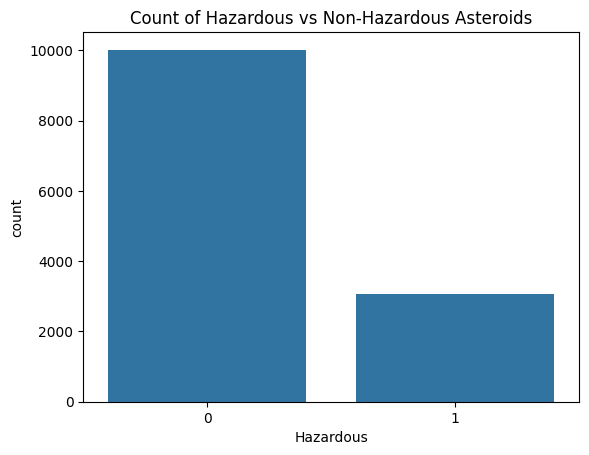

In [30]:
sns.countplot(x='Hazardous', data=df)
plt.title('Count of Hazardous vs Non-Hazardous Asteroids')
plt.show()

<span style="color:red">**Distribution of Numeric Features in the NASA + European Space Agency Asteroid Dataset**</span>

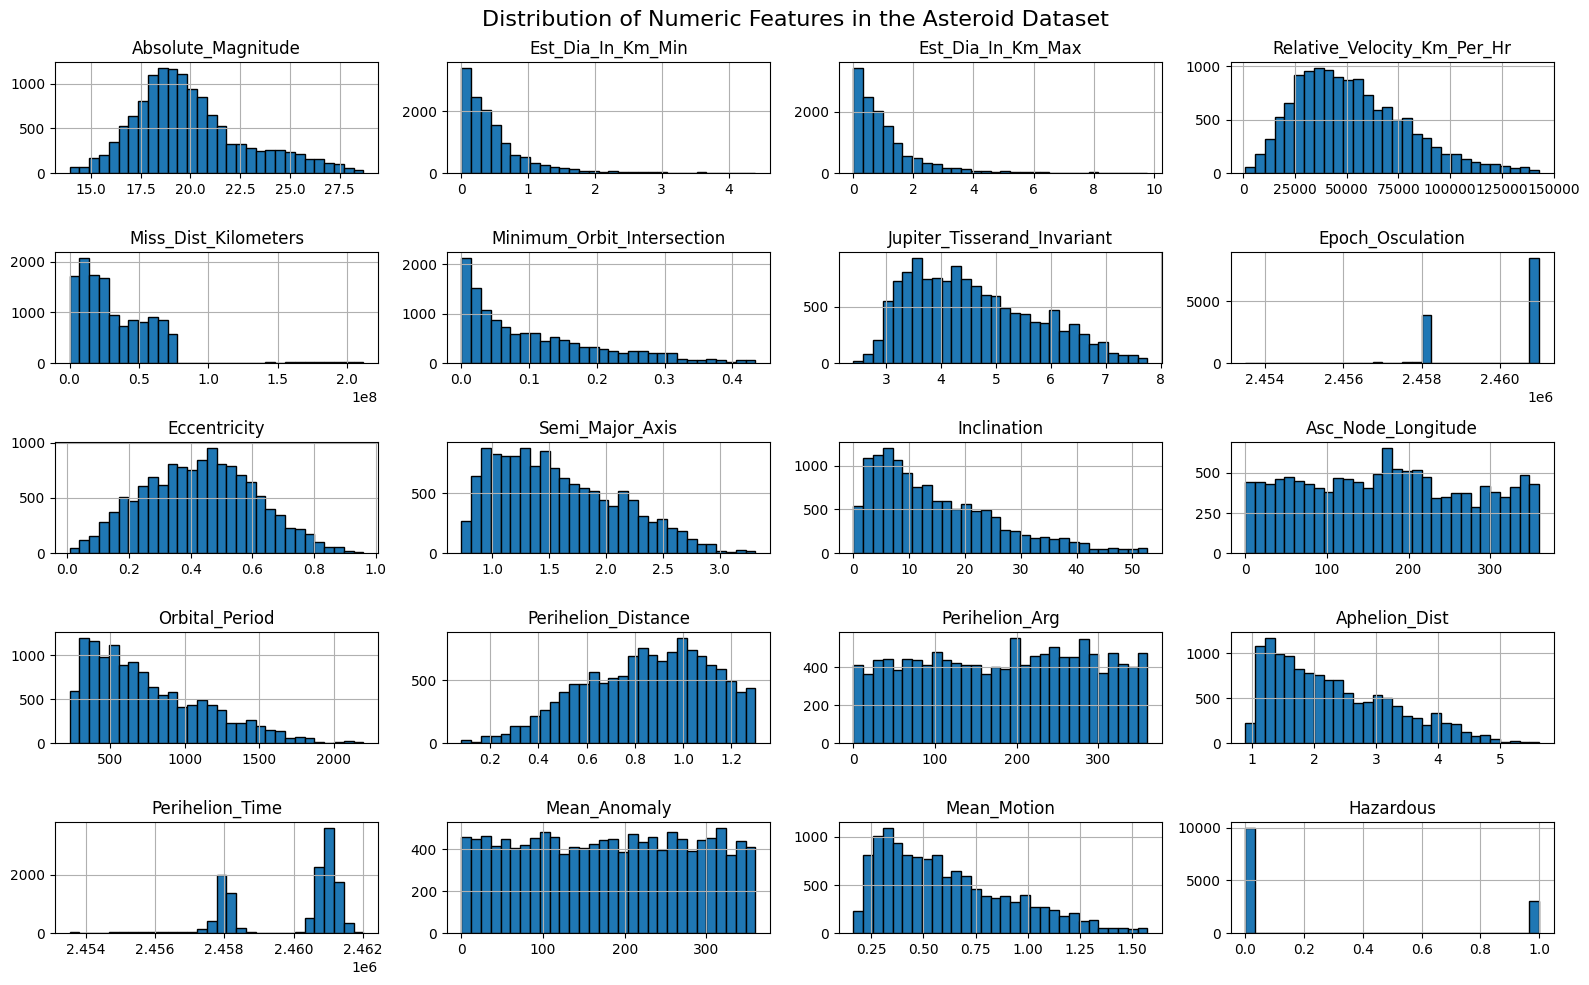

In [31]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

df[numeric_cols].hist(figsize=(16, 10), bins=30, edgecolor='black' )
plt.suptitle('Distribution of Numeric Features in the Asteroid Dataset', fontsize=16)
plt.tight_layout()
plt.show()


<span style="color:black">**Pairplot of Asteroid Features (takes too much memory, won't upload to github)**</span> 


In [32]:
#sns.pairplot(df, height=3, aspect=1.2)
#plt.suptitle('Pairplot of NASA Asteroid Features', fontsize=70)
#plt.show()

<span style="color:red">**Multivariate Analysis: Correlation Heatmap of Asteroid Features**</span>

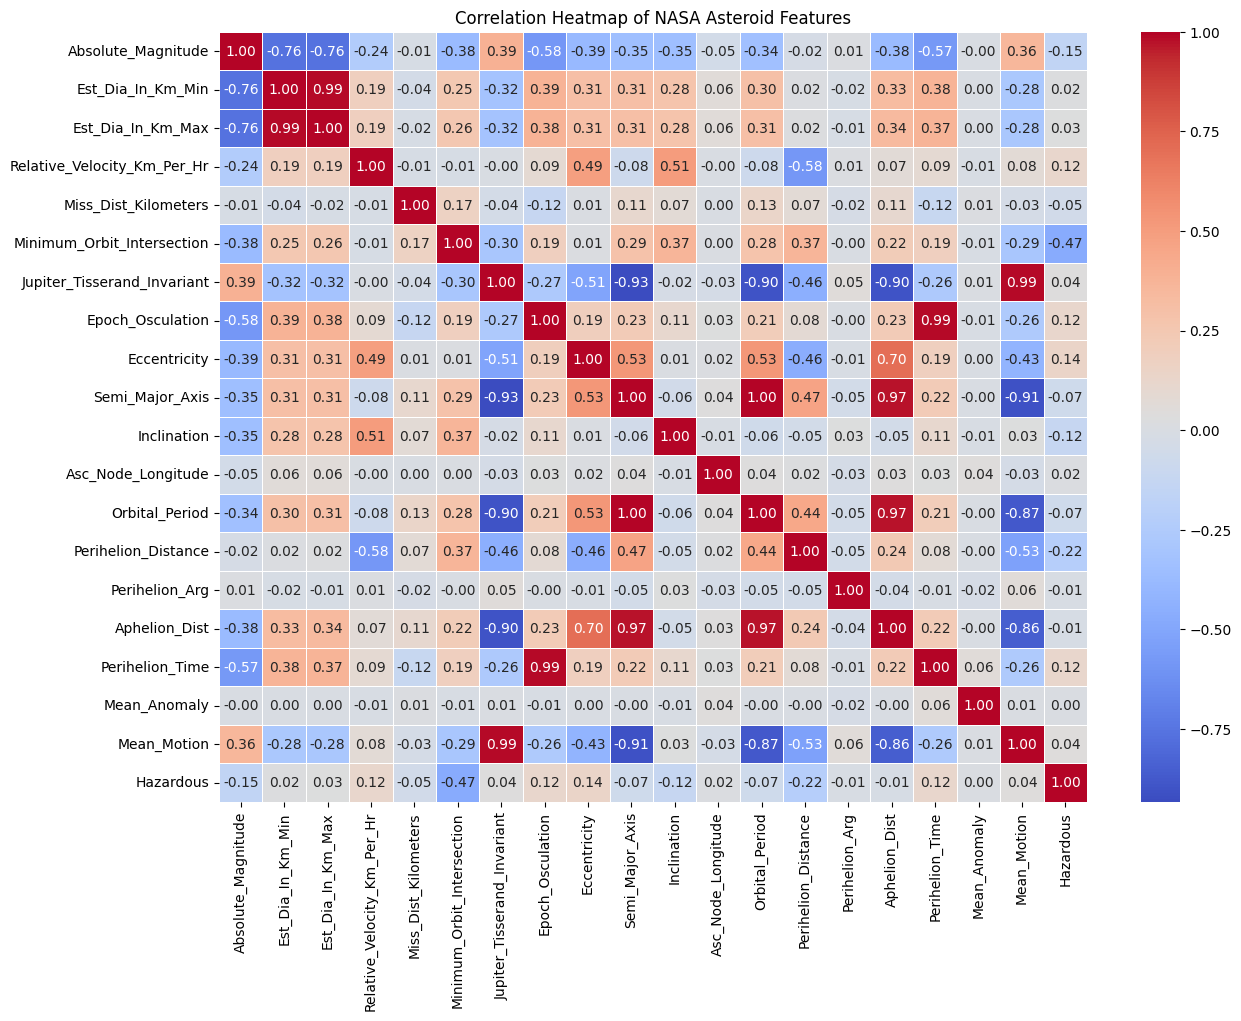

In [33]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of NASA Asteroid Features")
plt.show()




<span style="color:red">**Strong numerical corelation of Asteroid Features**</span>

In [34]:
# mask duplicate correlation pairs

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  

corr_pairs = corr.where(mask).stack().sort_values(ascending=False)

strong_corr = corr_pairs[(corr_pairs > 0.7) & (corr_pairs < 1)]

strong_corr

Semi_Major_Axis              Orbital_Period       0.996379
Jupiter_Tisserand_Invariant  Mean_Motion          0.991943
Epoch_Osculation             Perihelion_Time      0.987775
Est_Dia_In_Km_Min            Est_Dia_In_Km_Max    0.985586
Orbital_Period               Aphelion_Dist        0.973526
Semi_Major_Axis              Aphelion_Dist        0.971847
dtype: float64

<span style="color:red">**Bivariate Analysis**</span>

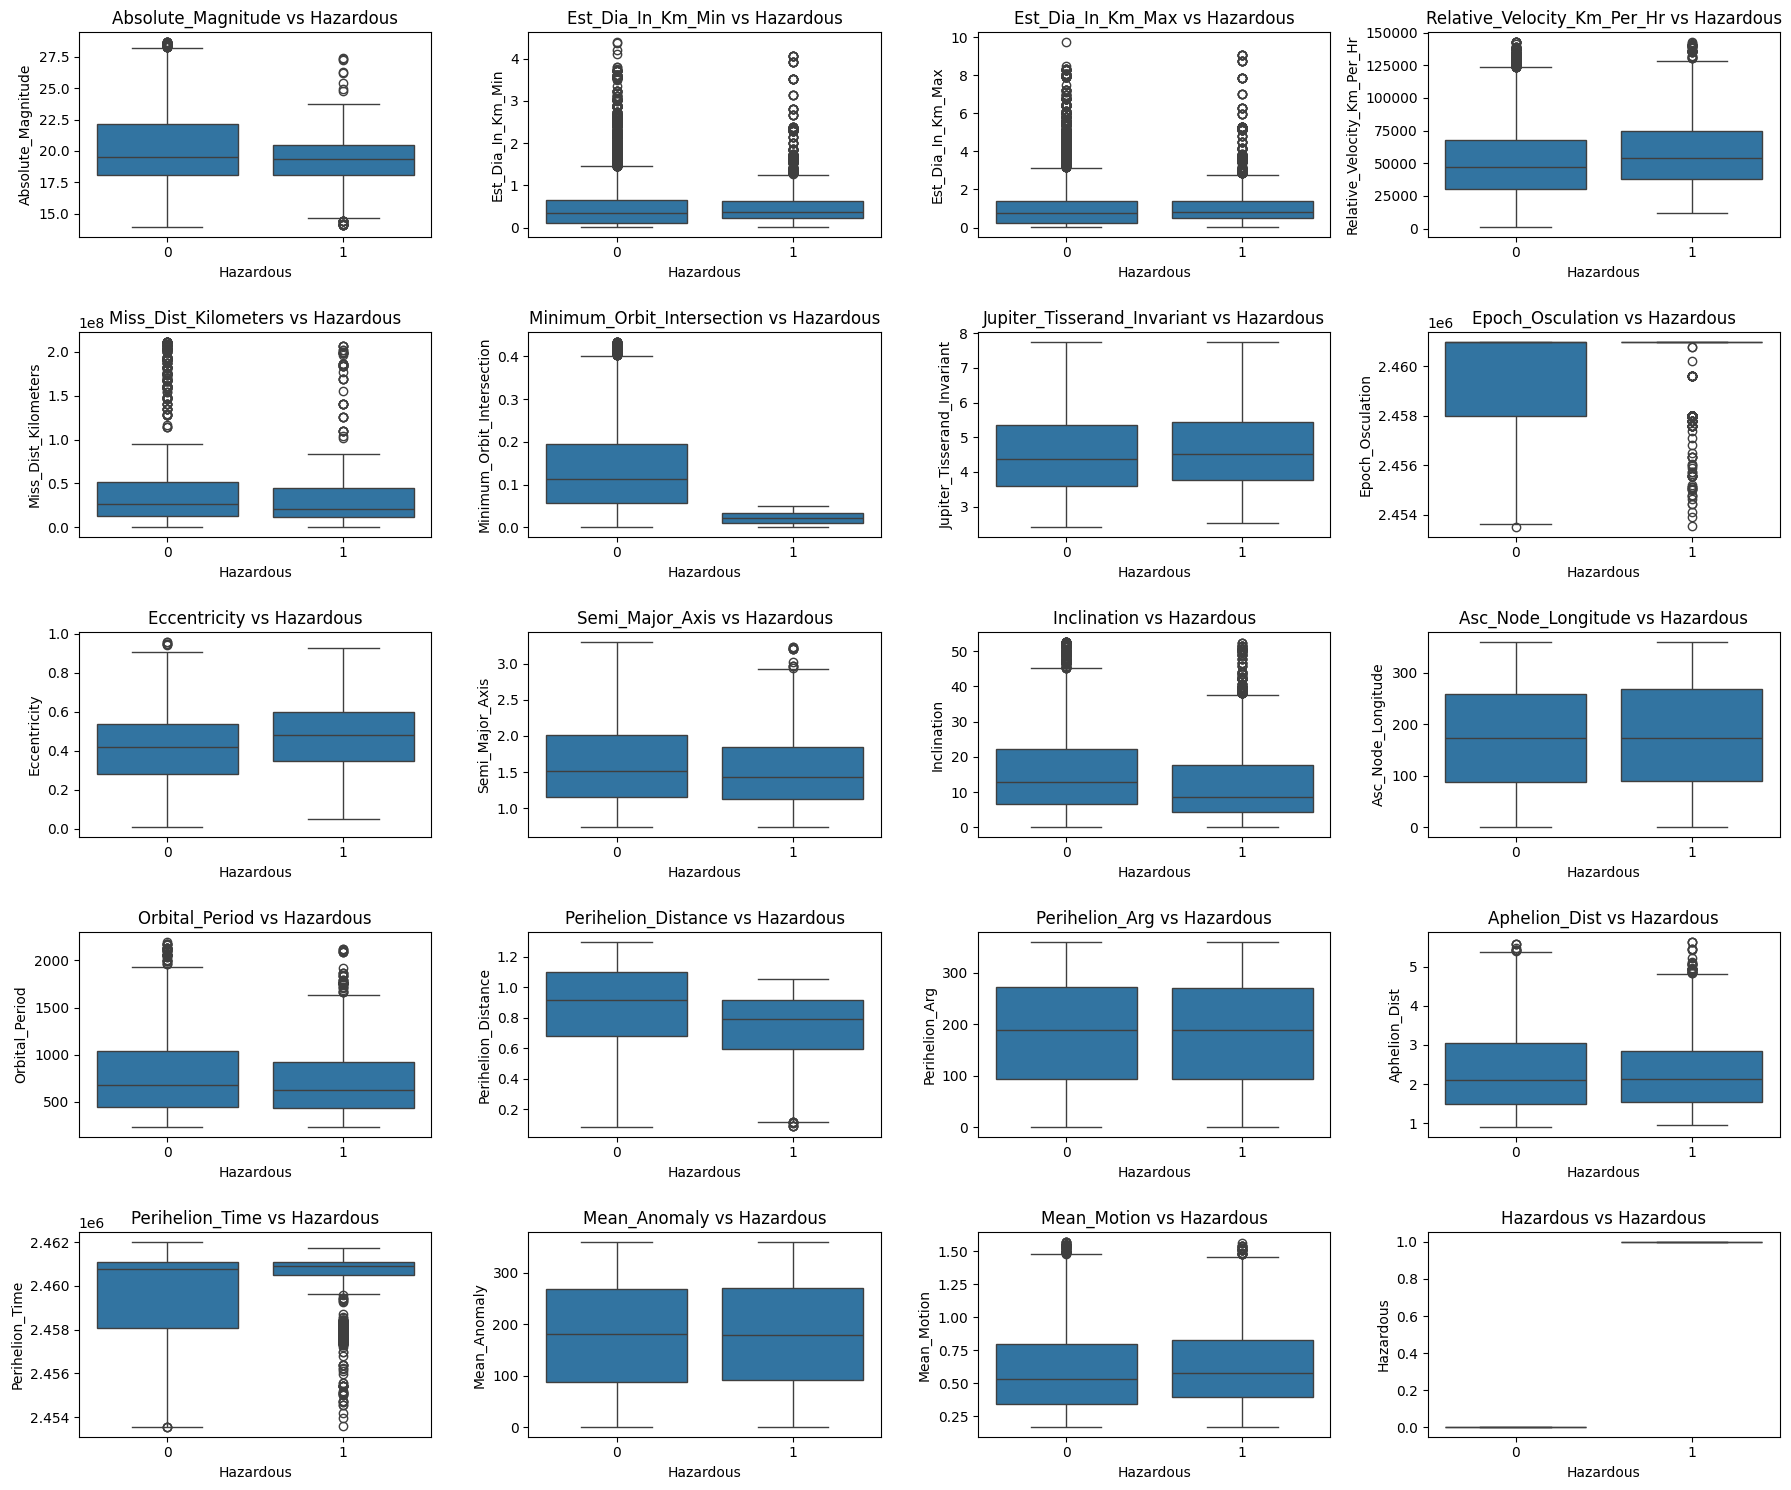

In [35]:
plt.figure(figsize=(18, 5 * 3))  

for i, col in enumerate(numeric_cols):
    plt.subplot(5, 4, i+1)  
    sns.boxplot(x='Hazardous', y=col, data=df)
    plt.title(f'{col} vs Hazardous')

plt.tight_layout()  
plt.show()

##### <span style="color:red">**Conclusions drawn from EDA analysis**</span>

In [36]:
# TODO

#### <span style="color:red">**Create ML Model**</span>

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13087 entries, 0 to 15962
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Absolute_Magnitude           13087 non-null  float64
 1   Est_Dia_In_Km_Min            13087 non-null  float64
 2   Est_Dia_In_Km_Max            13087 non-null  float64
 3   Close_Approach_Date          13087 non-null  object 
 4   Relative_Velocity_Km_Per_Hr  13087 non-null  float64
 5   Miss_Dist_Kilometers         13087 non-null  float64
 6   Minimum_Orbit_Intersection   13087 non-null  float64
 7   Jupiter_Tisserand_Invariant  13087 non-null  float64
 8   Epoch_Osculation             13087 non-null  float64
 9   Eccentricity                 13087 non-null  float64
 10  Semi_Major_Axis              13087 non-null  float64
 11  Inclination                  13087 non-null  float64
 12  Asc_Node_Longitude           13087 non-null  float64
 13  Orbital_Period       

<span style="color:red">**Close_Approach_Date is not an integer or a float, drop it**</span>

In [38]:
df = df.drop(columns=['Close_Approach_Date'])

<span style="color:red">**Split into features (X) and target (y)**</span>

In [39]:
X = df.drop(columns=['Hazardous'])
y = df['Hazardous']

<span style="color:red">**Train-test split**</span>

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


<span style="color:red">**Normalize**</span>

In [41]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<span style="color:red">**Build and train model**</span>

In [42]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


<span style="color:red">**Evaluate**</span>

In [43]:
y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9973262032085561


<span style="color:red">**Save model**</span>

In [44]:
MODEL = CWD / 'Model'
model_output_path = MODEL / 'hazard_model.pkl'
scaler_output_path = MODEL / 'scaler.pkl'

joblib.dump(model, model_output_path)
joblib.dump(scaler, scaler_output_path)


['c:\\Users\\ismai\\OneDrive\\Documents\\#Rutgers\\Data Management\\Model\\scaler.pkl']

<span style="color:red">**Save numerical ranges for realistic random value generation**</span>

In [45]:
# save numeric columns ranges to asteroids.db
db_path = CWD / 'Database' / 'asteroids.db'
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

for col in numeric_cols.drop('Hazardous'):
    min_val = df[col].min()
    max_val = df[col].max()
    cursor.execute('''
        INSERT OR REPLACE INTO feature_ranges (feature_name, min_value, max_value)
        VALUES (?, ?, ?)
    ''', (col, min_val, max_val))

conn.commit()
conn.close()